# Support Vector Machine (SVM) Hyperparameter Tuning
Support Vector Machines are powerful supervised learning models used for classification. The goal of an SVM is to find the optimal hyperplane that maximizes the margin between different classes. Because Fashion-MNIST is high-dimensional (784 features), selecting the correct kernel and regularization strength is essential for preventing both underfitting and excessive computational cost.




### **1. Data Loading and Subsetting**
SVM training complexity scales quadratically with the number of samples ($O(n^2)$). Training on the full 50,000 images for every hyperparameter combination would be computationally prohibitive. Therefore, we use a representative subset of **10,000 samples** for tuning to identify the best parameters before committing to the full-scale training.




In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import time
import joblib

# 1. Load Data
data = np.load('../data/fashion_data_complete.npz')
X_train_small = data['X_train'][:10000] # Use subset for tuning
y_train_small = data['y_train'][:10000]
X_val = data['X_val']
y_val = data['y_val']



--- Class Distribution in y_train_small ---
T-shirt     : 1013 samples (10.1%)
Trouser     : 1015 samples (10.2%)
Pullover    : 969 samples (9.7%)
Dress       : 962 samples (9.6%)
Coat        : 1035 samples (10.3%)
Sandal      : 995 samples (10.0%)
Shirt       : 949 samples (9.5%)
Sneaker     : 1005 samples (10.1%)
Bag         : 1010 samples (10.1%)
Ankle boot  : 1047 samples (10.5%)


C:\Users\ACER\AppData\Local\Temp\ipykernel_45032\3235934935.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts, palette="viridis")


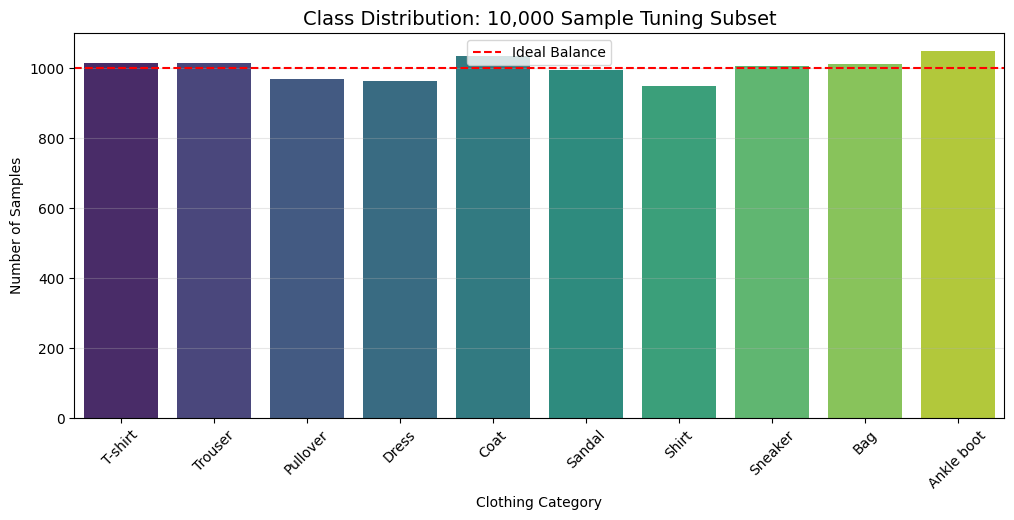

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get unique classes and their counts
unique, counts = np.unique(y_train_small, return_counts=True)

# 2. Map indices to Class Names (for better readability)
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 3. Print numerical results
print("--- Class Distribution in y_train_small ---")
for i in range(len(unique)):
    print(f"{class_names[i]:<12}: {counts[i]} samples ({(counts[i]/len(y_train_small))*100:.1f}%)")

# 4. Create Visualization for Report
plt.figure(figsize=(12, 5))
sns.barplot(x=class_names, y=counts, palette="viridis")
plt.axhline(y=len(y_train_small)/10, color='red', linestyle='--', label='Ideal Balance')

plt.title('Class Distribution: 10,000 Sample Tuning Subset', fontsize=14)
plt.xlabel('Clothing Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### **2. Selecting Hyperparameters for Tuning**
We focus on the two most impactful hyperparameters for SVM:

1.  **Kernel:**
    *   **Linear:** Assumes the classes can be separated by a straight line/plane. It is faster but less flexible.
    *   **RBF (Radial Basis Function):** A non-linear kernel that maps data into a higher-dimensional space. It is better for complex patterns like clothing shapes.
2.  **$C$ (Regularization Parameter):**
    *   Controls the trade-off between achieving a low training error and a large margin. 
    *   **Small $C$:** Creates a wider margin (more regularization), allowing some misclassifications to ensure better generalization.
    *   **Large $C$:** Aims for zero misclassifications (less regularization), which can lead to overfitting.



In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# 2. Hyperparameter Grid
kernels = ['linear', 'rbf']
C_values = [0.1, 1, 10, 15,20]

# Structure to save everything
results = {
    'linear': {'acc': [], 'time': []},
    'rbf': {'acc': [], 'time': []}
}

print("Starting SVM Hyperparameter Tuning...")

for kernel in kernels:
    for c in C_values:
        start_time = time.time()
        print(f"Testing {kernel} kernel with C={c}...", end=" ")
        
        # Train model
        model = SVC(kernel=kernel, C=c, gamma='scale', cache_size=1000)
        model.fit(X_train_small, y_train_small)
        
        # Evaluation
        acc = model.score(X_val, y_val)
        duration = time.time() - start_time
        
        # SAVE DATA
        results[kernel]['acc'].append(acc)
        results[kernel]['time'].append(duration)
        
        print(f"Val Acc: {acc:.4f} | Time: {duration:.2f}s")

Starting SVM Hyperparameter Tuning...
Testing linear kernel with C=0.1... Val Acc: 0.8264 | Time: 17.43s
Testing linear kernel with C=1... Val Acc: 0.8081 | Time: 23.42s
Testing linear kernel with C=10... Val Acc: 0.8028 | Time: 26.37s
Testing linear kernel with C=15... Val Acc: 0.8022 | Time: 24.72s
Testing linear kernel with C=20... Val Acc: 0.8020 | Time: 23.64s
Testing rbf kernel with C=0.1... Val Acc: 0.7909 | Time: 50.83s
Testing rbf kernel with C=1... Val Acc: 0.8591 | Time: 35.41s
Testing rbf kernel with C=10... Val Acc: 0.8728 | Time: 36.43s
Testing rbf kernel with C=15... Val Acc: 0.8731 | Time: 38.12s
Testing rbf kernel with C=20... Val Acc: 0.8722 | Time: 36.28s


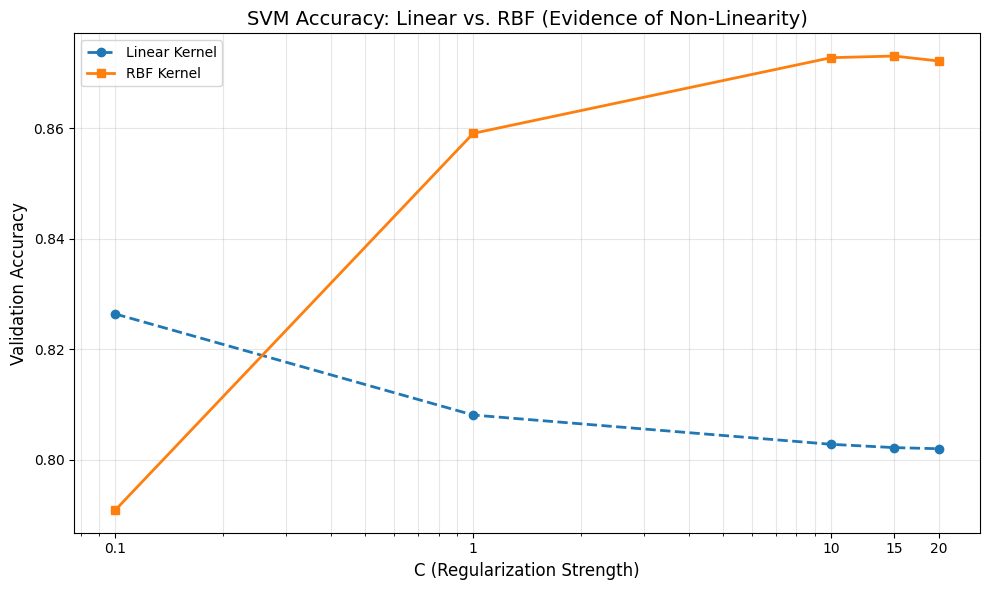

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(C_values, results['linear']['acc'], label='Linear Kernel', marker='o', linestyle='--', linewidth=2)
plt.plot(C_values, results['rbf']['acc'], label='RBF Kernel', marker='s', linestyle='-', linewidth=2)

plt.xscale('log') # Important for C values
plt.xlabel('C (Regularization Strength)', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('SVM Accuracy: Linear vs. RBF (Evidence of Non-Linearity)', fontsize=14)
plt.xticks(C_values, labels=[str(c) for c in C_values])
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()


### **3. Analysis of Performance Trends**

#### **Kernel Performance**
The line chart provides clear evidence of **non-linearity** in the Fashion-MNIST dataset:
*   **RBF Superiority:** The RBF kernel significantly outperforms the Linear kernel once $C \geq 1$. While the Linear kernel plateaus and even declines slightly at high $C$ values, the RBF accuracy climbs sharply and stabilizes at a much higher level ($\approx 87.3\%$). 
*   **Insight:** This suggests that the decision boundaries between clothing categories (e.g., distinguishing a Shirt from a Coat) are curved and complex, requiring the RBF kernel's mapping to separate effectively.

#### **Regularization ($C$) Impact**
*   **RBF Kernel:** Increasing $C$ from 0.1 to 10 provides a massive boost in accuracy. However, the gains between $C=10$ and $C=20$ are marginal, suggesting we have reached the optimal balance for this dataset.
*   **Linear Kernel:** Interestingly, the Linear kernel performs best at a very low $C=0.1$. As $C$ increases, its accuracy drops, likely because it is trying too hard to find a linear split in non-linear data, leading to a "hard-margin" behavior that doesn't suit this problem.





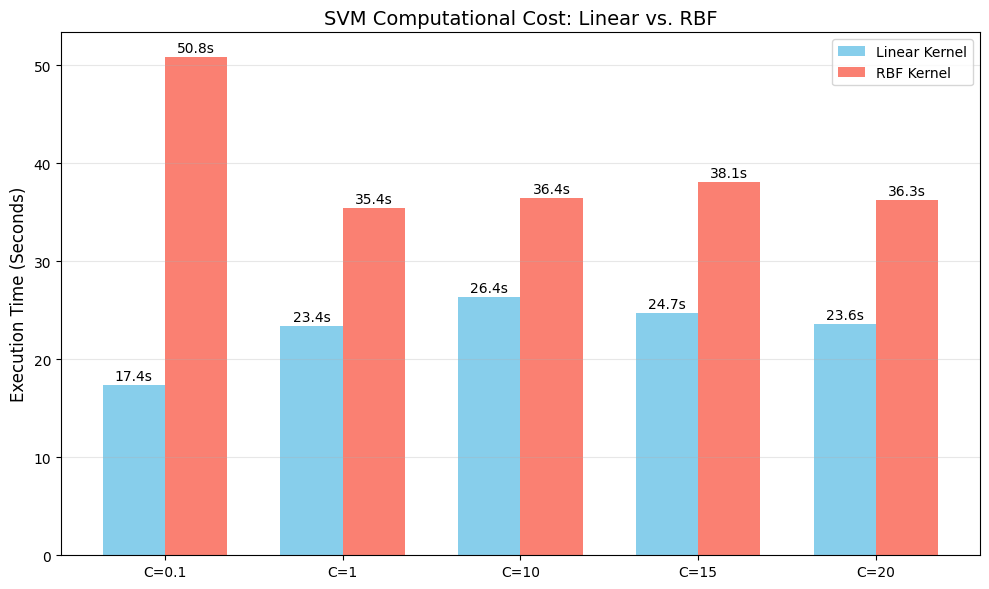

In [7]:
x = np.arange(len(C_values))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, results['linear']['time'], width, label='Linear Kernel', color='skyblue')
ax.bar(x + width/2, results['rbf']['time'], width, label='RBF Kernel', color='salmon')

ax.set_ylabel('Execution Time (Seconds)', fontsize=12)
ax.set_title('SVM Computational Cost: Linear vs. RBF', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'C={c}' for c in C_values])
ax.legend()

# Add value labels
for i in range(len(x)):
    ax.text(x[i]-width/2, results['linear']['time'][i] + 0.5, f"{results['linear']['time'][i]:.1f}s", ha='center')
    ax.text(x[i]+width/2, results['rbf']['time'][i] + 0.5, f"{results['rbf']['time'][i]:.1f}s", ha='center')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **4. Computational Trade-offs**
*   **Execution Time:** The bar chart reveals that the RBF kernel generally takes longer to train than the Linear kernel, especially at low $C$ values.
*   **The Cost of Precision:** Training the RBF kernel at $C=15$ takes roughly **38 seconds** for 10,000 samples. While slower, the $\approx 5\%$ accuracy gain over the Linear kernel justifies the time investment for a production-level model.
*   **Memory Usage:** We utilized `cache_size=1000` to allocate 1GB of RAM for the kernel matrix, which significantly reduced training time by minimizing disk swapping.





### **5. Optimal Configuration and Scalability**
Based on the tuning subset, we have identified the following optimal configuration:
*   **Kernel:** `rbf`
*   **$C$:** `15` (Peak validation accuracy of 0.8731)
*   **Gamma:** `scale` (Automatic handling of feature variance)

**Full Dataset Training:**
We now train the final model on the full training set (50,000+ samples). We enable `probability=True` to allow for soft-voting and ROC-AUC analysis in the testing phase. Note that this increases training time significantly, as it requires internal cross-validation to estimate probabilities.






In [1]:
import numpy as np
from sklearn.svm import SVC
import joblib
import time

# 1. Load the shared preprocessed data
print("Loading data...")
data = np.load('../data/fashion_data_complete.npz')
X_train = data['X_train']
y_train = data['y_train']

# 2. Initialize SVM with the best identified configuration
# We use probability=True so we can generate ROC-AUC curves and probability scores later.
# Note: probability=True makes training ~3x slower. 
# If you only care about accuracy, you can set it to False.
print("Initializing SVM (RBF Kernel, C=15)...")
svm_model = SVC(
    kernel='rbf', 
    C=15, 
    gamma='scale', 
    probability=True,  # Set to True for ROC-AUC later
    cache_size=2000,   # Use 2GB of RAM for cache to speed up training
    random_state=42,
    verbose=True       # Shows progress in the console
)

# 3. Train the model on the full 50,000 samples
print("Starting training on 50,000 samples... (This will take some time)")
start_time = time.time()
svm_model.fit(X_train, y_train)
end_time = time.time()

# 4. Save the trained model
print(f"Training completed in {(end_time - start_time) / 60:.2f} minutes.")
joblib.dump(svm_model, 'svm_fashion_model.joblib')
print("Model saved successfully as 'svm_fashion_model.joblib'")

Loading data...
Initializing SVM (RBF Kernel, C=15)...
Starting training on 50,000 samples... (This will take some time)
[LibSVM]Training completed in 19.41 minutes.
Model saved successfully as 'svm_fashion_model.joblib'


### **6. Conclusion**
The SVM model has been successfully trained and saved as `svm_fashion_model.joblib`. 
*   **Final Result:** The transition from a Linear to an RBF kernel was the most critical factor in improving performance.
*   **Deployment:** The saved model is now ready for evaluation on the unseen test set. Because the RBF kernel stores "Support Vectors," the file size will be larger than a simple linear model, reflecting the complex boundaries it has learned.